# The Social Media–Preventive Behavior Disconnect among University Students in Bangladesh
### A Cross-Sectional Mediation Study — Analysis Notebook

This notebook reproduces the full analytical pipeline reported in the manuscript: data cleaning and Likert encoding, scale construction and reliability screening, demographic profiling, correlations, hierarchical regression, bootstrapped parallel mediation (Health Belief Model + Theory of Planned Behavior), regression diagnostics, subgroup comparisons, and figure/table export. Section numbers in the headings below map to the corresponding sections of the paper.

**Sample:** N = 410 students from public and private universities. **Stack:** Python 3 (pandas, NumPy, SciPy, statsmodels, matplotlib) on Google Colab.

## 1. Environment Setup & Data Loading

**Plotting configuration.** Set a consistent serif font and base size so every figure produced later shares the same publication style.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

**Mount Google Drive.** Connect the Colab runtime to Drive, where the dataset and exported outputs are stored.

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load the dataset.** Read the 410-response survey export into a pandas DataFrame.

In [ ]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Preventive Health Behavior/Preventive Health Behavior Dataset.csv")

**Inspect the raw data.** Display the full DataFrame to confirm it loaded correctly before any cleaning.

In [ ]:
df

,Timestamp,SECTION A: Demographic Information\nAge,Gender,Type of University,Year of Study,Faculty,Living Arrangement,SECTION B: Frequency and Types of Preventive Health Behaviors\nHow often do you engage in the following preventive health behaviors? (Please give your opinion based on scaling) [I exercise at least 3 times a week. ],SECTION B: Frequency and Types of Preventive Health Behaviors\nHow often do you engage in the following preventive health behaviors? (Please give your opinion based on scaling) [I maintain a balanced diet.],SECTION B: Frequency and Types of Preventive Health Behaviors\nHow often do you engage in the following preventive health behaviors? (Please give your opinion based on scaling) [I attend regular medical check-ups.],...,SECTION E: Social Media Influence on Health Behavior\nPlease indicate how strongly you agree or disagree with the following statements ((Please give your opinion based on scaling). [Social media spreads both helpful and misleading health information.],"SECTION F: Summary\nIn the past 6 months, have you done any of the following? (Select all that apply)",SECTION G: Health Beliefs (HBM Constructs)\nPlease respond to the following items based on your beliefs.\n [I believe I am at risk of falling ill if I don’t take preventive measures.],"SECTION G: Health Beliefs (HBM Constructs)\nPlease respond to the following items based on your beliefs.\n [I think taking preventive action (e.g., screening, vaccination) is beneficial.]",SECTION G: Health Beliefs (HBM Constructs)\nPlease respond to the following items based on your beliefs.\n [I avoid preventive care due to cost or inconvenience.],SECTION G: Health Beliefs (HBM Constructs)\nPlease respond to the following items based on your beliefs.\n [I feel confident that I can take care of my health.],SECTION G: Health Beliefs (HBM Constructs)\nPlease respond to the following items based on your beliefs.\n [I plan to maintain regular preventive behaviors in the future.],SECTION H: Barriers and Challenges\nWhich are the barriers and challenges against improving preventive health initiatives and engagement among students.,SECTION I: Strategic and Initiatives\nWhich strategies would be helpful r for improving preventive health initiatives and engagement among students.,Thank you for your participation\n(Any Suggestion)
0,2025/05/22 8:43:11 PM GMT+6,21 - 25 Years,Female,Private University,1st Year,Science & Engineering,With Family,Never (1),Sometimes (3),Never (1),...,Strongly Disagree (5),Changed diet due to health awareness,Neutral (3),Agree (4),Agree (4),Agree (4),Strongly Disagree (1),Lack of time due to busy class schedule;Inadeq...,Cost prevention of preventive health services;...,NaN
1,2025/05/22 8:45:42 PM GMT+6,15 - 20 Years,Male,Private University,1st Year,Science & Engineering,With Family,Never (1),Never (1),Never (1),...,Neutral (3),Changed diet due to health awareness,Neutral (3),Neutral (3),Neutral (3),Neutral (3),Neutral (3),Health is often not a priority due to academic...,Avoiding fast food,NaN
2,2025/05/22 8:47:47 PM GMT+6,21 - 25 Years,Male,Private University,1st Year,Science & Engineering,Off - Campus,Often (4),Always (5),Never (1),...,Agree (4),Changed diet due to health awareness;Started a...,Agree (4),Agree (4),Neutral (3),Agree (4),Agree (4),Health is often not a priority due to academic...,Cost prevention of preventive health services;...,Welcome
3,2025/05/22 8:48:37 PM GMT+6,21 - 25 Years,Male,Private University,1st Year,Science & Engineering,Off - Campus,Sometimes (3),Rarely (2),Rarely (2),...,Neutral (3),Received a medical check-up,Agree (4),Agree (4),Disagree (2),Neutral (3),Disagree (2),Lack of time due to busy class schedule;Health...,Health education and awareness campaigns;Rewar...,Nothing
4,2025/05/22 8:50:54 PM GMT+6,15 - 20 Years,Male,Private University,1st Year,Science & Engineering,Off - Campus,Never (1),Never (1),Never (1),...,Neutral (3),Changed diet due to health awareness,Neutral (3),Neutral (3),Neutral (3),

**Suppress non-critical warnings.** Keep the analysis output focused on results.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## 2. Data Preprocessing (Manuscript 3.4)

**Step 1 — Rename columns.** Map the long survey questions to short, analysis-friendly variable names, grouped by questionnaire section (B–I).

In [ ]:
# Rename columns to clean, analysis-friendly names
# Safety check: confirm structure before renaming
assert df.shape[1] == 37, f"Expected 37 columns, found {df.shape[1]}"

clean_names = [
    "Timestamp",
    "Age", "Gender", "UniversityType", "YearOfStudy", "Faculty", "LivingArrangement",
    # Section B – Preventive Health Behavior (frequency)
    "B1_Exercise", "B2_Diet", "B3_Checkup", "B4_Vaccine", "B5_MentalCare", "B6_AvoidUnhealthy",
    # Section C – Peer Influence / Subjective Norms
    "C1_PeerSupport", "C2_FriendEncourage", "C3_ClassmatesCare", "C4_AvoidWeak_R", "C5_PeerTopic",
    # Section D – Institutional Support
    "D1_Visible", "D2_MedCenter", "D3_Campaigns", "D4_Trust", "D5_UsedSvc",
    # Section E – Social Media Influence  (key predictor block)
    "E1_Follow", "E2_TriedTips", "E3_TrustTips", "E4_Motivated", "E5_MixedInfo",
    # Section F – behaviors done in past 6 months (multi-select)
    "F_Past6Months",
    # Section G – Health Beliefs (HBM)
    "G1_Susceptib", "G2_Benefit", "G3_Barrier_R", "G4_SelfEff", "G5_Intention",
    # Section H & I – barriers / strategies (multi-select), plus open suggestion
    "H_Barriers", "I_Strategies", "Suggestion"
]

df.columns = clean_names

# Verify
print("New columns:")
for c in df.columns:
    print(" -", c)
print("\nShape:", df.shape)
df.head(3)

New columns:
 - Timestamp
 - Age
 - Gender
 - UniversityType
 - YearOfStudy
 - Faculty
 - LivingArrangement
 - B1_Exercise
 - B2_Diet
 - B3_Checkup
 - B4_Vaccine
 - B5_MentalCare
 - B6_AvoidUnhealthy
 - C1_PeerSupport
 - C2_FriendEncourage
 - C3_ClassmatesCare
 - C4_AvoidWeak_R
 - C5_PeerTopic
 - D1_Visible
 - D2_MedCenter
 - D3_Campaigns
 - D4_Trust
 - D5_UsedSvc
 - E1_Follow
 - E2_TriedTips
 - E3_TrustTips
 - E4_Motivated
 - E5_MixedInfo
 - F_Past6Months
 - G1_Susceptib
 - G2_Benefit
 - G3_Barrier_R
 - G4_SelfEff
 - G5_Intention
 - H_Barriers
 - I_Strategies
 - Suggestion

Shape: (410, 37)


,Timestamp,Age,Gender,UniversityType,YearOfStudy,Faculty,LivingArrangement,B1_Exercise,B2_Diet,B3_Checkup,...,E5_MixedInfo,F_Past6Months,G1_Susceptib,G2_Benefit,G3_Barrier_R,G4_SelfEff,G5_Intention,H_Barriers,I_Strategies,Suggestion
0,2025/05/22 8:43:11 PM GMT+6,21 - 25 Years,Female,Private University,1st Year,Science & Engineering,With Family,Never (1),Sometimes (3),Never (1),...,Strongly Disagree (5),Changed diet due to health awareness,Neutral (3),Agree (4),Agree (4),Agree (4),Strongly Disagree (1),Lack of time due to busy class schedule;Inadeq...,Cost prevention of preventive health services;...,NaN
1,2025/05/22 8:45:42 PM GMT+6,15 - 20 Years,Male,Private University,1st Year,Science & Engineering,With Family,Never (1),Never (1),Never (1),...,Neutral (3),Changed diet due to health awareness,Neutral (3),Neutral (3),Neutral (3),Neutral (3),Neutral (3),Health is often not a priority due to academic...,Avoiding fast food,NaN
2,2025/05/22 8:47:47 PM GMT+6,21 - 25 Years,Male,Private University,1st Year,Science & Engineering,Off - Campus,Often (4),Always (5),Never (1),...,Agree (4),Changed diet due to health awareness;Started a...,Agree (4),Agree (4),Neutral (3),Agree (4),Agree (4),Health is often not a priority due to academic...,Cost prevention of preventive health services;...,Welcome


**Step 2 — Encode Likert responses.** Convert the text anchors to numeric 1–5 scores. A coding inconsistency in the social-media block (displayed numeral vs. textual anchor) is resolved in favor of the textual label respondents actually selected.

In [ ]:
# Convert Likert text responses to numeric 1-5 (correct the form's coding error)
# Two response scales were used:
freq_map = {            # Section B (frequency)
    "Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5
}
agree_map = {           # Sections C, D, E, G (agreement)
    "Strongly Disagree": 1, "Disagree": 2, "Neutral": 3,
    "Agree": 4, "Strongly Agree": 5
}

freq_cols  = ["B1_Exercise","B2_Diet","B3_Checkup","B4_Vaccine","B5_MentalCare","B6_AvoidUnhealthy"]
agree_cols = ["C1_PeerSupport","C2_FriendEncourage","C3_ClassmatesCare","C4_AvoidWeak_R","C5_PeerTopic",
              "D1_Visible","D2_MedCenter","D3_Campaigns","D4_Trust","D5_UsedSvc",
              "E1_Follow","E2_TriedTips","E3_TrustTips","E4_Motivated","E5_MixedInfo",
              "G1_Susceptib","G2_Benefit","G3_Barrier_R","G4_SelfEff","G5_Intention"]

def label_part(x):
    """Take the text before '(' e.g. 'Strongly Disagree (5)' -> 'Strongly Disagree'."""
    if pd.isna(x):
        return x
    return str(x).split("(")[0].strip()

def paren_num(x):
    """Number inside parentheses, for cross-checking the form's own coding."""
    import re
    if pd.isna(x):
        return None
    m = re.search(r"\((\d)\)", str(x))
    return int(m.group(1)) if m else None

# --- Detect how many cells have a text-vs-number mismatch (the form error) ---
mismatches = 0
for col in freq_cols + agree_cols:
    use_map = freq_map if col in freq_cols else agree_map
    for v in df[col].dropna():
        lbl, pn = label_part(v), paren_num(v)
        if lbl in use_map and pn is not None and use_map[lbl] != pn:
            mismatches += 1
print(f"Cells where the printed number disagrees with the text label: {mismatches}")
print("(We trust the TEXT label, which corrects the form's mislabeling.)\n")

# --- Apply text-based mapping ---
for col in freq_cols:
    df[col] = df[col].map(label_part).map(freq_map)
for col in agree_cols:
    df[col] = df[col].map(label_part).map(agree_map)

likert_cols = freq_cols + agree_cols

# --- Verify: every Likert cell should now be an integer 1–5, no unexpected NaN ---
print("Value range across all Likert items:",
      int(df[likert_cols].min().min()), "to", int(df[likert_cols].max().max()))
print("Unexpected NaN introduced:", int(df[likert_cols].isna().sum().sum()))
print("\nDtypes check:")
print(df[likert_cols].dtypes.value_counts())

df[likert_cols].describe().T[["mean","std","min","max"]].round(2)

Cells where the printed number disagrees with the text label: 70
(We trust the TEXT label, which corrects the form's mislabeling.)

Value range across all Likert items: 1 to 5
Unexpected NaN introduced: 0

Dtypes check:
int64    26
Name: count, dtype: int64


,mean,std,min,max
B1_Exercise,2.31,1.17,1.0,5.0
B2_Diet,2.50,1.25,1.0,5.0
B3_Checkup,1.98,1.06,1.0,5.0
B4_Vaccine,2.88,1.45,1.0,5.0
B5_MentalCare,2.30,1.24,1.0,5.0
B6_AvoidUnhealthy,3.24,1.50,1.0,5.0
C1_PeerSupport,3.15,1.12,1.0,5.0
C2_FriendEncourage,2.95,1.10,1.0,5.0
C3_ClassmatesCare,2.74,1.11,1.0,5.0
C4_AvoidWeak_R,2.49,1.15,1.0,5.0


**Step 3 — Reverse-code and build initial scales.** Reverse the two negatively worded items, compute mean construct scores, and report initial Cronbach’s α.

In [ ]:
# Reverse-code negative items, build construct scores, check reliability
# Reverse-code the two negatively-worded items (1<->5, 2<->4, 3 stays)
reverse_items = ["C4_AvoidWeak_R", "G3_Barrier_R"]
for col in reverse_items:
    df[col] = 6 - df[col]
print("Reverse-coded:", reverse_items, "\n")

# Define construct -> item mapping
constructs = {
    "PreventiveBehavior": ["B1_Exercise","B2_Diet","B3_Checkup","B4_Vaccine","B5_MentalCare","B6_AvoidUnhealthy"],
    "PeerInfluence":      ["C1_PeerSupport","C2_FriendEncourage","C3_ClassmatesCare","C4_AvoidWeak_R","C5_PeerTopic"],
    "InstitutionalSupport":["D1_Visible","D2_MedCenter","D3_Campaigns","D4_Trust","D5_UsedSvc"],
    "SocialMedia":        ["E1_Follow","E2_TriedTips","E3_TrustTips","E4_Motivated","E5_MixedInfo"],
    "HealthBeliefs":      ["G1_Susceptib","G2_Benefit","G3_Barrier_R","G4_SelfEff","G5_Intention"],
}

# Cronbach's alpha
def cronbach_alpha(frame):
    frame = frame.dropna()
    k = frame.shape[1]
    item_var = frame.var(axis=0, ddof=1).sum()
    total_var = frame.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var / total_var)

# Build mean-score for each construct + report alpha
print(f"{'Construct':<22}{'Items':>6}{'Alpha':>9}")
print("-" * 37)
for name, items in constructs.items():
    df[name] = df[items].mean(axis=1)
    a = cronbach_alpha(df[items])
    flag = "  <-- low" if a < 0.70 else ""
    print(f"{name:<22}{len(items):>6}{a:>9.3f}{flag}")

print("\nConstruct score summary:")
score_cols = list(constructs.keys())
display(df[score_cols].describe().T[["mean","std","min","max"]].round(2))

Reverse-coded: ['C4_AvoidWeak_R', 'G3_Barrier_R'] 

Construct              Items    Alpha
-------------------------------------
PreventiveBehavior         6    0.735
PeerInfluence              5    0.440  <-- low
InstitutionalSupport       5    0.851
SocialMedia                5    0.813
HealthBeliefs              5    0.520  <-- low

Construct score summary:


,mean,std,min,max
PreventiveBehavior,2.53,0.84,1.0,5.0
PeerInfluence,3.02,0.62,1.4,4.8
InstitutionalSupport,2.87,0.92,1.0,5.0
SocialMedia,3.15,0.85,1.0,5.0
HealthBeliefs,3.30,0.65,1.4,4.8


**Step 4 — Item–total diagnostics.** Examine corrected item–total correlations and “α-if-deleted” for the two weak scales (peer influence and health beliefs), which flags the two reverse-coded items as malfunctioning.

In [ ]:
# Item-total reliability diagnostics for the two weak scales
def reliability_diagnostics(frame, construct_name):
    frame = frame.dropna()
    items = list(frame.columns)
    k = len(items)

    def alpha(f):
        kk = f.shape[1]
        return (kk/(kk-1)) * (1 - f.var(ddof=1).sum() / f.sum(axis=1).var(ddof=1))

    full_alpha = alpha(frame)
    print(f"\n=== {construct_name}  (current alpha = {full_alpha:.3f}, {k} items) ===")
    print(f"{'Item':<22}{'Corr_item_total':>16}{'Alpha_if_deleted':>18}")
    print("-" * 56)
    for it in items:
        rest = frame[[c for c in items if c != it]]
        # corrected item-total correlation (item vs sum of the OTHER items)
        cit = frame[it].corr(rest.sum(axis=1))
        a_del = alpha(rest)
        flag = "  <-- drop helps" if a_del > full_alpha else ""
        print(f"{it:<22}{cit:>16.3f}{a_del:>18.3f}{flag}")

reliability_diagnostics(df[constructs["PeerInfluence"]], "PeerInfluence")
reliability_diagnostics(df[constructs["HealthBeliefs"]], "HealthBeliefs")


=== PeerInfluence  (current alpha = 0.440, 5 items) ===
Item                   Corr_item_total  Alpha_if_deleted
--------------------------------------------------------
C1_PeerSupport                   0.491             0.175
C2_FriendEncourage               0.567             0.111
C3_ClassmatesCare                0.392             0.261
C4_AvoidWeak_R                  -0.419             0.767  <-- drop helps
C5_PeerTopic                     0.425             0.233

=== HealthBeliefs  (current alpha = 0.520, 5 items) ===
Item                   Corr_item_total  Alpha_if_deleted
--------------------------------------------------------
G1_Susceptib                     0.448             0.352
G2_Benefit                       0.574             0.267
G3_Barrier_R                    -0.393             0.797  <-- drop helps
G4_SelfEff                       0.495             0.330
G5_Intention                     0.589             0.257


**Step 5 — Finalize the scales.** Drop the two malfunctioning reverse-coded items (retained in the dataset for transparency) and recompute the final construct scores and reliabilities (α = 0.74–0.85).

In [ ]:
# Drop the two malfunctioning reverse items, rebuild scales
# Updated construct definitions (C4 and G3 removed on psychometric grounds)
constructs = {
    "PreventiveBehavior":   ["B1_Exercise","B2_Diet","B3_Checkup","B4_Vaccine","B5_MentalCare","B6_AvoidUnhealthy"],
    "PeerInfluence":        ["C1_PeerSupport","C2_FriendEncourage","C3_ClassmatesCare","C5_PeerTopic"],
    "InstitutionalSupport": ["D1_Visible","D2_MedCenter","D3_Campaigns","D4_Trust","D5_UsedSvc"],
    "SocialMedia":          ["E1_Follow","E2_TriedTips","E3_TrustTips","E4_Motivated","E5_MixedInfo"],
    "HealthBeliefs":        ["G1_Susceptib","G2_Benefit","G4_SelfEff","G5_Intention"],
}

def cronbach_alpha(frame):
    frame = frame.dropna()
    k = frame.shape[1]
    return (k/(k-1)) * (1 - frame.var(ddof=1).sum() / frame.sum(axis=1).var(ddof=1))

# Rebuild construct scores and report final alphas
print(f"{'Construct':<22}{'Items':>6}{'Alpha':>9}")
print("-" * 37)
for name, items in constructs.items():
    df[name] = df[items].mean(axis=1)
    a = cronbach_alpha(df[items])
    flag = "  <-- ok" if a >= 0.70 else "  <-- still low"
    print(f"{name:<22}{len(items):>6}{a:>9.3f}{flag}")

# Note for Methods: C4_AvoidWeak_R and G3_Barrier_R retained in df as raw items
# (for transparency/appendix) but EXCLUDED from construct scores.
dropped_items = ["C4_AvoidWeak_R", "G3_Barrier_R"]
print("\nExcluded from scales (kept in dataframe for reporting):", dropped_items)

print("\nFinal construct score summary:")
score_cols = list(constructs.keys())
display(df[score_cols].describe().T[["mean","std","min","max"]].round(2))

Construct              Items    Alpha
-------------------------------------
PreventiveBehavior         6    0.735  <-- ok
PeerInfluence              4    0.767  <-- ok
InstitutionalSupport       5    0.851  <-- ok
SocialMedia                5    0.813  <-- ok
HealthBeliefs              4    0.797  <-- ok

Excluded from scales (kept in dataframe for reporting): ['C4_AvoidWeak_R', 'G3_Barrier_R']

Final construct score summary:


,mean,std,min,max
PreventiveBehavior,2.53,0.84,1.0,5.0
PeerInfluence,2.90,0.85,1.0,5.0
InstitutionalSupport,2.87,0.92,1.0,5.0
SocialMedia,3.15,0.85,1.0,5.0
HealthBeliefs,3.38,0.88,1.0,5.0


## 3. Results (Manuscript 4)

### 3.1 Sample characteristics

**Table 1 — Demographic profile.** Frequency and percentage breakdown of the sample across age, gender, university type, year of study, faculty, and living arrangement.

In [ ]:
# Sample profile (Table 1 - demographics)
demo_vars = ["Age", "Gender", "UniversityType", "YearOfStudy", "Faculty", "LivingArrangement"]

print(f"Total respondents: N = {len(df)}\n")
print("="*45)
for var in demo_vars:
    print(f"\n{var}")
    print("-"*45)
    counts = df[var].value_counts(dropna=False)
    pct = df[var].value_counts(normalize=True, dropna=False) * 100
    for category in counts.index:
        print(f"  {str(category):<28}{counts[category]:>5}  ({pct[category]:>4.1f}%)")

# Also assemble as a tidy dataframe for export to your paper
rows = []
for var in demo_vars:
    counts = df[var].value_counts(dropna=False)
    pct = df[var].value_counts(normalize=True, dropna=False) * 100
    for category in counts.index:
        rows.append({"Variable": var, "Category": str(category),
                     "n": int(counts[category]), "Percent": round(pct[category], 1)})
table1 = pd.DataFrame(rows)
print("\n\nTidy Table 1 (first rows):")
display(table1.head(10))

Total respondents: N = 410


Age
---------------------------------------------
  21 - 25 Years                 302  (73.7%)
  26 - 30 Years                  53  (12.9%)
  15 - 20 Years                  39  ( 9.5%)
  Above 30 Years                 16  ( 3.9%)

Gender
---------------------------------------------
  Male                          240  (58.5%)
  Female                        169  (41.2%)
  Other                           1  ( 0.2%)

UniversityType
---------------------------------------------
  Private University            250  (61.0%)
  Public University             160  (39.0%)

YearOfStudy
---------------------------------------------
  4th Year                      110  (26.8%)
  1st Year                      101  (24.6%)
  2nd Year                       81  (19.8%)
  3rd Year                       67  (16.3%)
  Master's                       51  (12.4%)

Faculty
---------------------------------------------
  Science & Engineering         171  (41.7%)
  Social Science

,Variable,Category,n,Percent
0,Age,21 - 25 Years,302,73.7
1,Age,26 - 30 Years,53,12.9
2,Age,15 - 20 Years,39,9.5
3,Age,Above 30 Years,16,3.9
4,Gender,Male,240,58.5
5,Gender,Female,169,41.2
6,Gender,Other,1,0.2
7,UniversityType,Private University,250,61.0
8,UniversityType,Public University,160,39.0
9,YearOfStudy,4th Year,110,26.8


### 3.2 Correlations

**Table 3 — Construct correlation matrix.** Pearson correlations among the five constructs, with significance stars and a spotlight on each construct’s zero-order correlation with preventive behavior.

In [ ]:
# Correlation matrix among constructs (Table 3)
from scipy import stats
import numpy as np

score_cols = ["PreventiveBehavior","PeerInfluence","InstitutionalSupport","SocialMedia","HealthBeliefs"]

# Pearson r matrix
corr = df[score_cols].corr(method="pearson")

# Matching p-value matrix
pvals = pd.DataFrame(np.ones((len(score_cols), len(score_cols))),
                     index=score_cols, columns=score_cols)
for a in score_cols:
    for b in score_cols:
        if a != b:
            r, p = stats.pearsonr(df[a], df[b])
            pvals.loc[a, b] = p

def stars(p):
    return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else ""

# Display r with significance stars (lower triangle)
print("Correlation matrix (Pearson r, *** p<.001, ** p<.01, * p<.05)\n")
print(f"{'':<22}" + "".join(f"{c[:8]:>11}" for c in score_cols))
for i, a in enumerate(score_cols):
    row = f"{a:<22}"
    for j, b in enumerate(score_cols):
        if j < i:
            row += f"{corr.loc[a,b]:>8.3f}{stars(pvals.loc[a,b]):<3}"
        elif j == i:
            row += f"{'1':>8}   "
        else:
            row += f"{'':>11}"
    print(row)

print("\nFull r matrix (rounded):")
display(corr.round(3))

# Spotlight: every construct's correlation with the outcome
print("\nZero-order correlation with Preventive Behavior:")
for c in score_cols[1:]:
    r, p = stats.pearsonr(df["PreventiveBehavior"], df[c])
    print(f"  {c:<22} r = {r:.3f}{stars(p)}   (p = {p:.4f})")

Correlation matrix (Pearson r, *** p<.001, ** p<.01, * p<.05)

                         Preventi   PeerInfl   Institut   SocialMe   HealthBe
PreventiveBehavior           1                                               
PeerInfluence            0.416***       1                                    
InstitutionalSupport     0.279***   0.412***       1                         
SocialMedia              0.228***   0.381***   0.386***       1              
HealthBeliefs            0.394***   0.446***   0.346***   0.506***       1   

Full r matrix (rounded):


,PreventiveBehavior,PeerInfluence,InstitutionalSupport,SocialMedia,HealthBeliefs
PreventiveBehavior,1.000,0.416,0.279,0.228,0.394
PeerInfluence,0.416,1.000,0.412,0.381,0.446
InstitutionalSupport,0.279,0.412,1.000,0.386,0.346
SocialMedia,0.228,0.381,0.386,1.000,0.506
HealthBeliefs,0.394,0.446,0.346,0.506,1.000



Zero-order correlation with Preventive Behavior:
  PeerInfluence          r = 0.416***   (p = 0.0000)
  InstitutionalSupport   r = 0.279***   (p = 0.0000)
  SocialMedia            r = 0.228***   (p = 0.0000)
  HealthBeliefs          r = 0.394***   (p = 0.0000)


### 3.3 Hierarchical regression

**Table 4 — Two-step OLS.** Model 1 enters social media alone; Model 2 adds peer influence, institutional support, and health beliefs, revealing the social-media coefficient collapsing to non-significance under adjustment.

In [ ]:
# Hierarchical regression (Table 4) - does social media survive adjustment?
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Standardize constructs (z-scores) so coefficients are comparable betas
z = df.copy()
for c in score_cols:
    z[c + "_z"] = (df[c] - df[c].mean()) / df[c].std()

# Model 1: Social media alone
m1 = smf.ols("PreventiveBehavior_z ~ SocialMedia_z", data=z).fit()

# Model 2: Add peer, institutional, health beliefs
m2 = smf.ols("PreventiveBehavior_z ~ SocialMedia_z + PeerInfluence_z "
             "+ InstitutionalSupport_z + HealthBeliefs_z", data=z).fit()

def report(model, label):
    print(f"\n{'='*52}\n{label}")
    print(f"R² = {model.rsquared:.3f} | Adj R² = {model.rsquared_adj:.3f} "
          f"| F = {model.fvalue:.2f}, p = {model.f_pvalue:.4g} | n = {int(model.nobs)}")
    print(f"{'Predictor':<24}{'beta':>9}{'SE':>8}{'t':>8}{'p':>10}")
    print("-"*59)
    for v in model.params.index:
        name = v.replace("_z","").replace("Intercept","(Intercept)")
        print(f"{name:<24}{model.params[v]:>9.3f}{model.bse[v]:>8.3f}"
              f"{model.tvalues[v]:>8.2f}{model.pvalues[v]:>10.4g}")

report(m1, "MODEL 1: Social Media only")
report(m2, "MODEL 2: + Peer, Institutional, Health Beliefs")

# The key contrast: social media's beta before vs after
b_before = m1.params["SocialMedia_z"]
b_after  = m2.params["SocialMedia_z"]
p_after  = m2.pvalues["SocialMedia_z"]
print(f"\n{'*'*52}")
print(f"Social media beta:  {b_before:.3f} (alone)  -->  {b_after:.3f} (adjusted)")
print(f"Adjusted p-value = {p_after:.4f}  "
      f"--> {'STILL significant' if p_after < .05 else 'NO LONGER significant'}")
print(f"R² change (Model 1 -> Model 2): {m2.rsquared - m1.rsquared:+.3f}")


MODEL 1: Social Media only
R² = 0.052 | Adj R² = 0.050 | F = 22.44, p = 3e-06 | n = 410
Predictor                    beta      SE       t         p
-----------------------------------------------------------
(Intercept)                 0.000   0.048    0.00         1
SocialMedia                 0.228   0.048    4.74     3e-06

MODEL 2: + Peer, Institutional, Health Beliefs
R² = 0.234 | Adj R² = 0.227 | F = 31.00, p = 1.559e-22 | n = 410
Predictor                    beta      SE       t         p
-----------------------------------------------------------
(Intercept)                 0.000   0.043    0.00         1
SocialMedia                -0.045   0.053   -0.86    0.3893
PeerInfluence               0.280   0.051    5.43 9.646e-08
InstitutionalSupport        0.092   0.050    1.84   0.06619
HealthBeliefs               0.261   0.053    4.88 1.533e-06

****************************************************
Social media beta:  0.228 (alone)  -->  -0.045 (adjusted)
Adjusted p-value = 0.3893 

### 3.4 Mediation analysis

**Table 5 — Bootstrapped parallel mediation.** Decompose social media’s total effect into a direct path (cʹ) and indirect paths through health beliefs and peer influence (5,000 resamples, 95% percentile CIs).

In [ ]:
# Parallel mediation (Table 5) - does social media act indirectly through beliefs & norms?
# X = SocialMedia, Mediators = HealthBeliefs, PeerInfluence, Y = PreventiveBehavior
import numpy as np
import statsmodels.formula.api as smf

rng = np.random.default_rng(42)
d = df[["PreventiveBehavior","SocialMedia","HealthBeliefs","PeerInfluence"]].dropna().reset_index(drop=True)

def indirect_effects(data):
    # a-paths: X -> each mediator
    a_HB = smf.ols("HealthBeliefs ~ SocialMedia", data=data).fit().params["SocialMedia"]
    a_PI = smf.ols("PeerInfluence ~ SocialMedia", data=data).fit().params["SocialMedia"]
    # b-paths + c' (direct): Y ~ X + mediators
    my = smf.ols("PreventiveBehavior ~ SocialMedia + HealthBeliefs + PeerInfluence", data=data).fit()
    b_HB, b_PI = my.params["HealthBeliefs"], my.params["PeerInfluence"]
    c_direct = my.params["SocialMedia"]
    return {
        "ind_HealthBeliefs": a_HB * b_HB,
        "ind_PeerInfluence": a_PI * b_PI,
        "ind_total": a_HB*b_HB + a_PI*b_PI,
        "direct": c_direct,
    }

# Total effect c (X -> Y, no mediators)
c_total = smf.ols("PreventiveBehavior ~ SocialMedia", data=d).fit().params["SocialMedia"]
point = indirect_effects(d)

# Bootstrap 5000 resamples for percentile CIs
B = 5000
keys = ["ind_HealthBeliefs","ind_PeerInfluence","ind_total","direct"]
boot = {k: np.empty(B) for k in keys}
for i in range(B):
    samp = d.iloc[rng.integers(0, len(d), len(d))]
    est = indirect_effects(samp)
    for k in keys:
        boot[k][i] = est[k]

print("Mediation of Social Media -> Preventive Behavior")
print(f"Mediators: Health Beliefs, Peer Influence | n = {len(d)} | 5000 bootstrap samples\n")
print(f"Total effect  (c)        = {c_total:.3f}")
print(f"Direct effect (c')       = {point['direct']:.3f}\n")
print(f"{'Indirect path':<26}{'estimate':>10}{'95% CI':>22}")
print("-"*58)
for k in ["ind_HealthBeliefs","ind_PeerInfluence","ind_total"]:
    lo, hi = np.percentile(boot[k], [2.5, 97.5])
    sig = "  significant" if (lo > 0 or hi < 0) else "  n.s."
    label = k.replace("ind_","via ")
    print(f"{label:<26}{point[k]:>10.3f}   [{lo:>6.3f}, {hi:>6.3f}]{sig}")

prop = point["ind_total"] / c_total * 100
print(f"\nProportion of total effect that is INDIRECT: {prop:.1f}%")
print("(Direct effect is n.s.; if indirect CIs exclude 0 => full mediation pattern.)")

Mediation of Social Media -> Preventive Behavior
Mediators: Health Beliefs, Peer Influence | n = 410 | 5000 bootstrap samples

Total effect  (c)        = 0.226
Direct effect (c')       = -0.024

Indirect path               estimate                95% CI
----------------------------------------------------------
via HealthBeliefs              0.135   [ 0.077,  0.198]  significant
via PeerInfluence              0.115   [ 0.067,  0.168]  significant
via total                      0.250   [ 0.183,  0.321]  significant

Proportion of total effect that is INDIRECT: 110.8%
(Direct effect is n.s.; if indirect CIs exclude 0 => full mediation pattern.)


### 3.5 Regression diagnostics

**Assumption checks.** Variance inflation factors (multicollinearity), Shapiro–Wilk residual normality, and the Breusch–Pagan test for homoscedasticity, confirming OLS is appropriate.

In [ ]:
# Regression diagnostics for the main model
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

predictors = ["SocialMedia", "PeerInfluence", "InstitutionalSupport", "HealthBeliefs"]

# Refit the main model (unstandardized) for diagnostics
X = sm.add_constant(df[predictors])
y = df["PreventiveBehavior"]
model = sm.OLS(y, X).fit()

# 1) Variance Inflation Factor (multicollinearity) — VIF < 5 is fine, < 10 acceptable
print("=== Multicollinearity (VIF) ===")
print(f"{'Predictor':<24}{'VIF':>8}")
print("-"*32)
for i, col in enumerate(X.columns):
    if col == "const":
        continue
    vif = variance_inflation_factor(X.values, i)
    flag = "  <-- check" if vif >= 5 else "  ok"
    print(f"{col:<24}{vif:>8.2f}{flag}")

# 2) Residual normality
resid = model.resid
sw_stat, sw_p = stats.shapiro(resid)
print(f"\n=== Residual normality (Shapiro-Wilk) ===")
print(f"W = {sw_stat:.3f}, p = {sw_p:.4f}  "
      f"-> {'residuals ~ normal' if sw_p > .05 else 'mild non-normality (OK for n=410, CLT)'}")
print(f"Skewness = {stats.skew(resid):.3f} | Kurtosis = {stats.kurtosis(resid):.3f}")

# 3) Homoscedasticity (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(resid, X)
print(f"\n=== Homoscedasticity (Breusch-Pagan) ===")
print(f"LM stat = {bp[0]:.3f}, p = {bp[1]:.4f}  "
      f"-> {'constant variance' if bp[1] > .05 else 'some heteroscedasticity (consider robust SE)'}")

# 4) Overall model fit summary
print(f"\n=== Model fit ===")
print(f"R2 = {model.rsquared:.3f} | Adj R2 = {model.rsquared_adj:.3f} "
      f"| F({int(model.df_model)}, {int(model.df_resid)}) = {model.fvalue:.2f}, "
      f"p = {model.f_pvalue:.4g}")

=== Multicollinearity (VIF) ===
Predictor                    VIF
--------------------------------
SocialMedia                 1.47  ok
PeerInfluence               1.40  ok
InstitutionalSupport        1.31  ok
HealthBeliefs               1.51  ok

=== Residual normality (Shapiro-Wilk) ===
W = 0.993, p = 0.0376  -> mild non-normality (OK for n=410, CLT)
Skewness = 0.310 | Kurtosis = 0.014

=== Homoscedasticity (Breusch-Pagan) ===
LM stat = 7.063, p = 0.1326  -> constant variance

=== Model fit ===
R2 = 0.234 | Adj R2 = 0.227 | F(4, 405) = 31.00, p = 1.559e-22


### 3.6 Subgroup comparisons

**Table 6 — Group differences.** Independent-samples t-tests (university type, gender) and a one-way ANOVA (living arrangement), each reported with Cohen’s d.

In [ ]:
# Subgroup comparisons (Table 6) on preventive behavior & constructs
from scipy import stats
import numpy as np

score_cols = ["PreventiveBehavior","PeerInfluence","InstitutionalSupport","SocialMedia","HealthBeliefs"]

def cohen_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled

# ---- 1) University type (independent t-test: Public vs Private) ----
print("="*60)
print("UNIVERSITY TYPE  (Public vs Private)")
print("="*60)
pub = df[df.UniversityType.str.contains("Public")]
pri = df[df.UniversityType.str.contains("Private")]
print(f"{'Construct':<22}{'Public':>9}{'Private':>9}{'t':>8}{'p':>9}{'d':>7}")
print("-"*64)
for c in score_cols:
    t, p = stats.ttest_ind(pub[c], pri[c])
    d = cohen_d(pub[c], pri[c])
    star = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else ""
    print(f"{c:<22}{pub[c].mean():>9.2f}{pri[c].mean():>9.2f}{t:>8.2f}{p:>9.4f}{d:>7.2f}{star}")

# ---- 2) Gender (Male vs Female; 'Other' n=1 excluded from test) ----
print("\n" + "="*60)
print("GENDER  (Male vs Female; 1 'Other' excluded from test)")
print("="*60)
male = df[df.Gender=="Male"]
fem  = df[df.Gender=="Female"]
print(f"{'Construct':<22}{'Male':>9}{'Female':>9}{'t':>8}{'p':>9}{'d':>7}")
print("-"*64)
for c in score_cols:
    t, p = stats.ttest_ind(male[c], fem[c])
    d = cohen_d(male[c], fem[c])
    star = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else ""
    print(f"{c:<22}{male[c].mean():>9.2f}{fem[c].mean():>9.2f}{t:>8.2f}{p:>9.4f}{d:>7.2f}{star}")

# ---- 3) Living arrangement (one-way ANOVA across 3 groups) ----
print("\n" + "="*60)
print("LIVING ARRANGEMENT  (one-way ANOVA)")
print("="*60)
groups = {k: df[df.LivingArrangement==k] for k in df.LivingArrangement.unique()}
print(f"{'Construct':<22}" + "".join(f"{k[:11]:>13}" for k in groups) + f"{'F':>8}{'p':>9}")
print("-"*(22+13*len(groups)+17))
for c in score_cols:
    samples = [g[c] for g in groups.values()]
    F, p = stats.f_oneway(*samples)
    star = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else ""
    means = "".join(f"{g[c].mean():>13.2f}" for g in groups.values())
    print(f"{c:<22}{means}{F:>8.2f}{p:>9.4f}{star}")

print("\n(* p<.05, ** p<.01, *** p<.001 | d = Cohen's d effect size)")

UNIVERSITY TYPE  (Public vs Private)
Construct                Public  Private       t        p      d
----------------------------------------------------------------
PreventiveBehavior         2.37     2.64   -3.29   0.0011  -0.33**
PeerInfluence              2.75     3.01   -3.06   0.0024  -0.31**
InstitutionalSupport       2.71     2.97   -2.75   0.0063  -0.28**
SocialMedia                3.14     3.16   -0.28   0.7774  -0.03
HealthBeliefs              3.31     3.41   -1.12   0.2619  -0.11

GENDER  (Male vs Female; 1 'Other' excluded from test)
Construct                  Male   Female       t        p      d
----------------------------------------------------------------
PreventiveBehavior         2.46     2.63   -1.98   0.0479  -0.20*
PeerInfluence              2.81     3.03   -2.48   0.0134  -0.25*
InstitutionalSupport       2.81     2.95   -1.53   0.1256  -0.15
SocialMedia                3.09     3.24   -1.79   0.0738  -0.18
HealthBeliefs              3.28     3.51   -2.57   0.0

**Tukey HSD post-hoc.** Pairwise comparisons across the three living-arrangement groups for the constructs with a significant omnibus ANOVA.

In [ ]:
# Tukey HSD post-hoc for living arrangement
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sig_constructs = ["PreventiveBehavior", "InstitutionalSupport", "HealthBeliefs"]

for c in sig_constructs:
    print("="*60)
    print(f"Tukey HSD: {c} by Living Arrangement")
    print("="*60)
    tukey = pairwise_tukeyhsd(endog=df[c], groups=df["LivingArrangement"], alpha=0.05)
    # Tidy print of the comparison table
    res = tukey.summary().data
    header = res[0]
    print(f"{'Group 1':<14}{'Group 2':<14}{'MeanDiff':>10}{'p-adj':>9}{'Reject':>9}")
    print("-"*56)
    for row in res[1:]:
        g1, g2, diff, padj = row[0], row[1], row[2], row[3]
        reject = row[6]
        print(f"{str(g1):<14}{str(g2):<14}{diff:>10.3f}{padj:>9.4f}{str(reject):>9}")
    print()

Tukey HSD: PreventiveBehavior by Living Arrangement
Group 1       Group 2         MeanDiff    p-adj   Reject
--------------------------------------------------------
Off - Campus  On - Campus       -0.240   0.0484     True
Off - Campus  With Family        0.107   0.5342    False
On - Campus   With Family        0.347   0.0017     True

Tukey HSD: InstitutionalSupport by Living Arrangement
Group 1       Group 2         MeanDiff    p-adj   Reject
--------------------------------------------------------
Off - Campus  On - Campus       -0.122   0.5180    False
Off - Campus  With Family        0.240   0.0755    False
On - Campus   With Family        0.362   0.0031     True

Tukey HSD: HealthBeliefs by Living Arrangement
Group 1       Group 2         MeanDiff    p-adj   Reject
--------------------------------------------------------
Off - Campus  On - Campus       -0.106   0.5773    False
Off - Campus  With Family        0.210   0.1134    False
On - Campus   With Family        0.316   0.0076

### 3.7 Behaviors, barriers, and strategies

**Multi-select tallies (raw).** Count responses to the multiple-response items on past-6-month actions, perceived barriers, and endorsed strategies.

In [ ]:
# Multi-select breakdown - past behaviors, barriers, strategies
import pandas as pd
from collections import Counter

def multiselect_table(series, title, top=None):
    counter = Counter()
    n_respondents = series.notna().sum()
    for val in series.dropna():
        # split on semicolons; clean whitespace and trailing fragments
        for part in str(val).split(";"):
            p = part.strip().rstrip(",").strip()
            if p and p.lower() not in {"etc.)", "..."}:
                counter[p] += 1
    print("="*70)
    print(f"{title}   (N = {n_respondents} respondents, multi-select)")
    print("="*70)
    print(f"{'Option':<52}{'n':>6}{'% of resp':>11}")
    print("-"*70)
    items = counter.most_common(top)
    for opt, cnt in items:
        pct = cnt / n_respondents * 100
        print(f"{opt[:50]:<52}{cnt:>6}{pct:>10.1f}%")
    print()
    return counter

# Section F — what students actually did in past 6 months
f_counts = multiselect_table(df["F_Past6Months"],
            "SECTION F: Preventive actions in past 6 months")

# Section H — barriers
h_counts = multiselect_table(df["H_Barriers"],
            "SECTION H: Barriers to preventive health", top=12)

# Section I — strategies endorsed
i_counts = multiselect_table(df["I_Strategies"],
            "SECTION I: Student-endorsed strategies", top=12)

SECTION F: Preventive actions in past 6 months   (N = 410 respondents, multi-select)
Option                                                   n  % of resp
----------------------------------------------------------------------
Changed diet due to health awareness                   185      45.1%
Received a medical check-up                            171      41.7%
Started an exercise routine                            164      40.0%
Got vaccinated (COVID, flu, etc.)                      115      28.0%
Nothing                                                 83      20.2%
Consulted a mental health professional                  78      19.0%
Participated in a university health awareness even      73      17.8%

SECTION H: Barriers to preventive health   (N = 410 respondents, multi-select)
Option                                                   n  % of resp
----------------------------------------------------------------------
Lack of time due to busy class schedule                251     

**Table 7 — Cleaned multi-select tables.** Restrict the tallies to the predefined questionnaire options, separating out free-text “Other” responses.

In [ ]:
# Clean multi-select tables (Table 7) - keep only predefined options
import pandas as pd
from collections import Counter

# Predefined response options from the questionnaire (anything else = free-text "Other")
valid_options = {
    "F_Past6Months": {
        "Received a medical check-up", "Got vaccinated (COVID, flu, etc.)",
        "Consulted a mental health professional", "Changed diet due to health awareness",
        "Started an exercise routine", "Participated in a university health awareness event",
        "Nothing",
    },
    "H_Barriers": {
        "Lack of time due to busy class schedule", "Inadequate on-campus health facilities",
        "Health is often not a priority due to academic pressure",
        "Unaware about preventive health practices", "Cultural and social barriers",
        "Financial constraint", "Discourage of peer group", "Availability of fast food",
    },
    "I_Strategies": {
        "Cost prevention of preventive health services",
        "Health education and awareness campaigns",
        "Encouraging peer to take preventive health services",
        "Reward participation in fitness programs with certificates.",
        "Avoiding fast food",
    },
}

def clean_table(series, valid_set, title):
    counter = Counter()
    n = series.notna().sum()
    other = 0
    for val in series.dropna():
        for part in str(val).split(";"):
            p = part.strip().rstrip(",").strip()
            if not p or p.lower() in {"etc.)", "..."}:
                continue
            if p in valid_set:
                counter[p] += 1
            else:
                other += 1
    print("="*72)
    print(f"{title}   (N = {n}, multi-select)")
    print("="*72)
    print(f"{'Option':<54}{'n':>6}{'% of resp':>11}")
    print("-"*72)
    rows = []
    for opt, cnt in counter.most_common():
        pct = cnt / n * 100
        print(f"{opt[:52]:<54}{cnt:>6}{pct:>10.1f}%")
        rows.append({"Option": opt, "n": cnt, "Percent": round(pct, 1)})
    print(f"{'(free-text Other responses)':<54}{other:>6}")
    print()
    return pd.DataFrame(rows)

tableF = clean_table(df["F_Past6Months"], valid_options["F_Past6Months"],
                     "SECTION F: Preventive actions in past 6 months")
tableH = clean_table(df["H_Barriers"], valid_options["H_Barriers"],
                     "SECTION H: Barriers to preventive health")
tableI = clean_table(df["I_Strategies"], valid_options["I_Strategies"],
                     "SECTION I: Student-endorsed strategies")

SECTION F: Preventive actions in past 6 months   (N = 410, multi-select)
Option                                                     n  % of resp
------------------------------------------------------------------------
Changed diet due to health awareness                     185      45.1%
Received a medical check-up                              171      41.7%
Started an exercise routine                              164      40.0%
Got vaccinated (COVID, flu, etc.)                        115      28.0%
Nothing                                                   83      20.2%
Consulted a mental health professional                    78      19.0%
Participated in a university health awareness event       73      17.8%
(free-text Other responses)                                0

SECTION H: Barriers to preventive health   (N = 410, multi-select)
Option                                                     n  % of resp
------------------------------------------------------------------------
Lack

## 4. Figures & Export

**Figure 2 — The social-media disconnect.** Two-panel figure: (A) zero-order vs. adjusted associations, where social media collapses toward zero; (B) decomposition of the total effect into a non-significant direct path and significant indirect paths. Saved at 300 dpi.

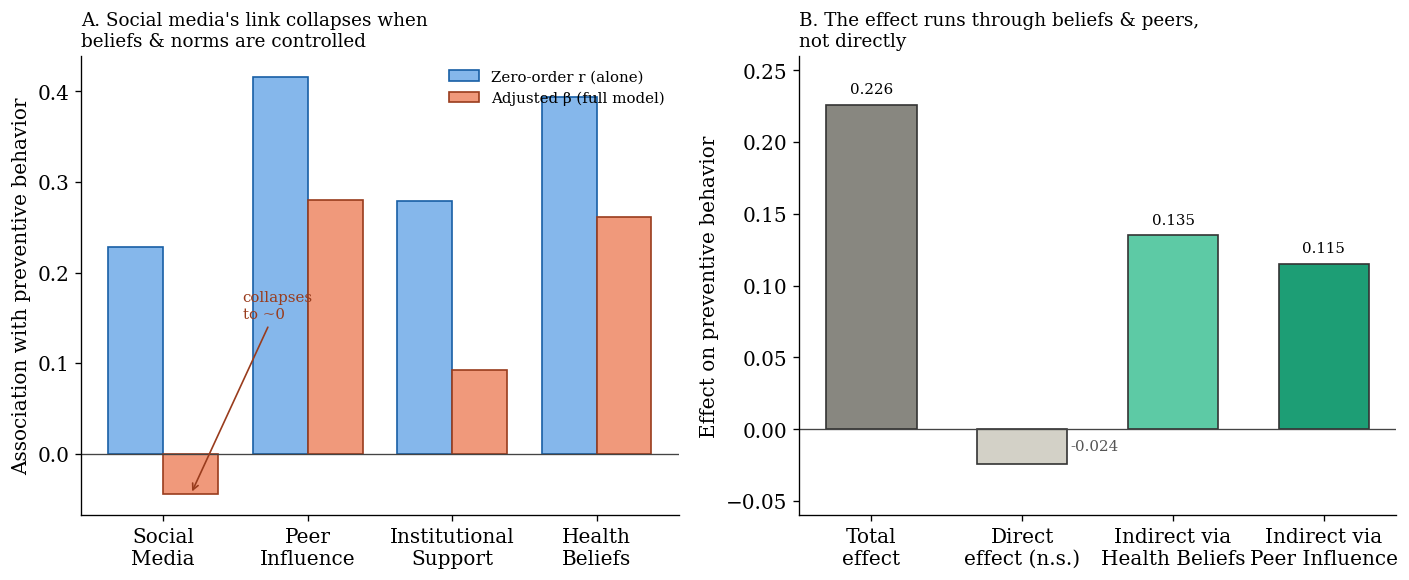

Re-saved corrected 300-dpi figure.


In [ ]:
# Figure 2 - two-panel 'social-media disconnect' figure (300 dpi)
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 12, "font.family": "serif",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 120,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ---- Panel A (unchanged) ----
labels = ["Social\nMedia", "Peer\nInfluence", "Institutional\nSupport", "Health\nBeliefs"]
zero_order = [0.228, 0.416, 0.279, 0.394]
adj_beta   = [-0.045, 0.280, 0.092, 0.261]
x = np.arange(4); w = 0.38
ax1.bar(x - w/2, zero_order, w, label="Zero-order r (alone)", color="#85B7EB", edgecolor="#185FA5")
ax1.bar(x + w/2, adj_beta, w, label="Adjusted \u03b2 (full model)", color="#F0997B", edgecolor="#993C1D")
ax1.axhline(0, color="#444", lw=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel("Association with preventive behavior")
ax1.set_title("A. Social media's link collapses when\nbeliefs & norms are controlled", fontsize=11, loc="left")
ax1.legend(frameon=False, fontsize=9, loc="upper right")
ax1.annotate("collapses\nto ~0", xy=(0+w/2, -0.045), xytext=(0.55, 0.15),
             fontsize=9, color="#993C1D",
             arrowprops=dict(arrowstyle="->", color="#993C1D"))

# ---- Panel B (label placement fixed) ----
parts = ["Total\neffect", "Direct\neffect (n.s.)", "Indirect via\nHealth Beliefs", "Indirect via\nPeer Influence"]
vals  = [0.226, -0.024, 0.135, 0.115]
colors = ["#888780", "#D3D1C7", "#5DCAA5", "#1D9E75"]
xb = np.arange(4)
bars = ax2.bar(xb, vals, 0.6, color=colors, edgecolor="#333")
ax2.axhline(0, color="#444", lw=0.8)
ax2.set_xticks(xb); ax2.set_xticklabels(parts)
ax2.set_ylabel("Effect on preventive behavior")
ax2.set_title("B. The effect runs through beliefs & peers,\nnot directly", fontsize=11, loc="left")
ax2.set_ylim(-0.06, 0.26)  # headroom so labels clear the axis

for b, v in zip(bars, vals):
    if v >= 0:
        ax2.text(b.get_x()+b.get_width()/2, v + 0.006, f"{v:.3f}",
                 ha="center", va="bottom", fontsize=9)
    else:
        # negative bar: place label to the RIGHT of the bar, above the axis line
        ax2.text(b.get_x()+b.get_width()+0.02, v/2, f"{v:.3f}",
                 ha="left", va="center", fontsize=9, color="#555")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Preventive Health Behavior/Figure_SocialMedia_Disconnect.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Re-saved corrected 300-dpi figure.")

## **Thank You.**